# TD03 — Perceptron multi-couche et rétropropagation

## Objectif

Un perceptron (TD01) puis une couche mono-couche (TD02) ne séparent que des données **linéairement séparables**. Ici on **empile des couches** et on apprend les poids par **rétropropagation du gradient** (cours « 4 - Rétropropagation »).

On procède en deux temps :
1. Implémenter un **perceptron à une couche cachée** (2 couches), le **valider** avec des fonctions de test, et lui faire apprendre **XOR**.
2. **Généraliser** à un MLP à $n$ couches, puis lui faire apprendre des **fonctions** en 1D et 2D (régression), avec **split train/test** et **early stopping**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

## 1. Fonctions d'activation

Le cours utilise une activation générique $A$. Pour la rétropropagation, on a besoin de $A$ **et** de sa dérivée $A'$ :

- sigmoïde : $\sigma(z) = \frac{1}{1+e^{-z}}$, $\sigma'(z) = \sigma(z)(1-\sigma(z))$
- tangente hyperbolique : $\tanh'(z) = 1 - \tanh^2(z)$

> **Exercice 1** — Complétez `sigmoid_prime` et `tanh_prime`.

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_prime(z: np.ndarray) -> np.ndarray:
    """
    σ'(z) = σ(z) · (1 - σ(z)).
    """
    # BEGIN
    s = sigmoid(z)
    return s * (1.0 - s)
    # END


def tanh_prime(z: np.ndarray) -> np.ndarray:
    """
    tanh'(z) = 1 - tanh²(z).
    """
    # BEGIN
    return 1.0 - np.tanh(z) ** 2
    # END

In [3]:
ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (np.tanh, tanh_prime),
    "linear": (lambda z: z, lambda z: np.ones_like(z)),
}

## 2. Perceptron à une couche cachée

On commence par le réseau le plus simple possible qui sache faire XOR : **une seule couche cachée** (2 couches de poids). C'est le cas « deux couches de neurones » du cours (§2.2.2).

Convention **ligne** : chaque échantillon est une ligne de la matrice. Pour un batch $X$ de forme $(N, d)$ :

### Notations

| Symbole | Signification |
|---|---|
| $N$ | nombre d'échantillons du batch |
| $d$ | nombre de features en entrée |
| $h$ | nombre de neurones de la couche cachée |
| $k$ | nombre de neurones de sortie |
| $X$ | batch d'entrée, de forme $(N, d)$ |
| $W_1$ | matrice de poids de la couche cachée, de forme $(h, d)$ |
| $b_1$ | biais de la couche cachée, de forme $(h,)$ |
| $W_2$ | matrice de poids de la couche de sortie, de forme $(k, h)$ |
| $b_2$ | biais de la couche de sortie, de forme $(k,)$ |
| $Z_1$ | pré-activations de la couche cachée |
| $Y_1$ | activations de la couche cachée, de forme $(N, h)$ |
| $Z_2$ | pré-activations de la couche de sortie |
| $Y_2$ | sortie du réseau, $Y = Y_2$, de forme $(N, k)$ |
| $A$ | fonction d'activation de la couche cachée (`activation`) ; $A'$ sa dérivée |
| $A_o$ | fonction d'activation de la couche de sortie (`output_activation`) ; $A_o'$ sa dérivée |
| $T$ | cibles, de même forme que $Y$ |
| $E$ | coût (erreur quadratique moyenne) |
| $\delta_1, \delta_2$ | erreurs rétropropagées de la couche cachée et de la couche de sortie |
| $\odot$ | produit terme à terme (Hadamard) |

### Passe avant

$$Z_1 = X W_1^T + b_1, \qquad Y_1 = A(Z_1), \qquad Z_2 = Y_1 W_2^T + b_2, \qquad Y = Y_2 = A_o(Z_2)$$

### Coût

$$E = \tfrac12\,\operatorname{mean}\big((Y - T)^2\big)$$

### Passe arrière

$$\delta_2 = (Y_2 - T)\odot A_o'(Z_2), \qquad \frac{\partial E}{\partial W_2} = \tfrac{1}{N}\,\delta_2^T Y_1, \qquad \frac{\partial E}{\partial b_2} = \tfrac{1}{N}\sum_i \delta_2$$

$$\delta_1 = (\delta_2\, W_2)\odot A'(Z_1), \qquad \frac{\partial E}{\partial W_1} = \tfrac{1}{N}\,\delta_1^T X, \qquad \frac{\partial E}{\partial b_1} = \tfrac{1}{N}\sum_i \delta_1$$

> **Exercice 2** — Complétez `forward` (renvoie $X, Z_1, Y_1, Z_2, Y_2$).

> **Exercice 3** — Complétez `backward` (renvoie `(dW1, db1), (dW2, db2)`).

> **Exercice 4** — Complétez `fit` (descente de gradient par lot, retourne l'historique du coût).

In [4]:
class PerceptronCache:
    def __init__(self, n_in, n_hidden, n_out, activation="sigmoid", output_activation="sigmoid", seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0.0, 0.5, size=(n_hidden, n_in))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0.0, 0.5, size=(n_out, n_hidden))
        self.b2 = np.zeros(n_out)
        self.activation, self.activation_prime = ACTIVATIONS[activation]
        self.output_activation, self.output_activation_prime = ACTIVATIONS[output_activation]


    def predict(self, X):
        return self.forward(X)[-1]

    def loss(self, X: np.ndarray, t: np.ndarray) -> float:
        """Coût du modèle : erreur quadratique moyenne.

        E = (1/2) · mean(Σ_k (Y_k - T_k)²).

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).

        Returns
        -------
        float
            Coût quadratique moyen sur le batch.
        """
        # BEGIN
        return 0.5 * float(np.mean(np.sum((self.predict(X) - t) ** 2, axis=1)))
        # END

    def forward(self, X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Passe avant du perceptron à une couche cachée.

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).

        Returns
        -------
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]
            (Y0, Z1, Y1, Z2, Y2) : entrée, pré-activations et activations
            de la couche cachée puis de la couche de sortie.
        """
        # BEGIN
        Y0 = X
        Z1 = Y0 @ self.W1.T + self.b1
        Y1 = self.activation(Z1)
        Z2 = Y1 @ self.W2.T + self.b2
        Y2 = self.output_activation(Z2)
        return Y0, Z1, Y1, Z2, Y2
        # END

    
    def backward(self, X: np.ndarray, t: np.ndarray) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
        """Passe arrière : gradients du coût par rapport aux paramètres.

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).

        Returns
        -------
        tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]
            ((dW1, db1), (dW2, db2)) : gradients pour chaque couche.
        """
        # BEGIN
        Y0, Z1, Y1, Z2, Y2 = self.forward(X)
        N = X.shape[0]
        delta2 = (Y2 - t) * self.output_activation_prime(Z2)
        dW2 = delta2.T @ Y1 / N
        db2 = delta2.sum(axis=0) / N
        delta1 = (delta2 @ self.W2) * self.activation_prime(Z1)
        dW1 = delta1.T @ Y0 / N
        db1 = delta1.sum(axis=0) / N
        return (dW1, db1), (dW2, db2)
        # END

    def _step(self, X: np.ndarray, t: np.ndarray, lr: float) -> None:
        """Effectue une étape de descente de gradient (mise à jour des poids).

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).
        lr : float
            Pas d'apprentissage.
        """
        # BEGIN
        (dW1, db1), (dW2, db2) = self.backward(X, t)
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        # END
    
    def fit(self, X: np.ndarray, t: np.ndarray, lr: float = 0.5, epochs: int = 10000) -> list[float]:
        """Entraîne le réseau par descente de gradient

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).
        lr : float, optionnel
            Pas d'apprentissage (défaut : 0.5).
        epochs : int, optionnel
            Nombre d'epochs (défaut : 10000).

        Returns
        -------
        list[float]
            Historique du coût, un élément par epoch.
        """
        # BEGIN
        history = []
        for epoch in range(epochs):
            self._step(X, t, lr)
            history.append(self.loss(X, t))
        return history
        # END

## 3. Fonctions de test / validation

Avant de croire qu'un réseau marche, on **valide** ses méthodes. `forward` est comparé à une passe avant naïve ; `backward` à un gradient **numérique** (différences finies). Si le réseau est faux, ces tests le disent tout de suite.

### Vérification de `forward`

On recompute $Z_1, Y_1, Z_2, Y_2$ à la main (sans boucle sur les couches) et on compare, plus la cohérence `predict` ↔ `forward`.

In [5]:
def check_forward(model, X, tol=1e-9):
    Y0, Z1, Y1, Z2, Y2 = model.forward(X)
    assert Y0.shape == X.shape, "Y0 doit être X"
    assert np.allclose(Y0, X, atol=tol), "Y0 != X"
    Z1r = X @ model.W1.T + model.b1
    Y1r = model.activation(Z1r)
    Z2r = Y1r @ model.W2.T + model.b2
    Y2r = model.output_activation(Z2r)
    assert Z1.shape == Z1r.shape, "forme Z1 incorrecte"
    assert Y1.shape == Y1r.shape, "forme Y1 incorrecte"
    assert Z2.shape == Z2r.shape, "forme Z2 incorrecte"
    assert Y2.shape == Y2r.shape, "forme Y2 incorrecte"
    assert np.allclose(Z1, Z1r, atol=tol), "Z1 incorrect"
    assert np.allclose(Y1, Y1r, atol=tol), "Y1 incorrect"
    assert np.allclose(Z2, Z2r, atol=tol), "Z2 incorrect"
    assert np.allclose(Y2, Y2r, atol=tol), "Y2 incorrect"
    assert np.allclose(model.predict(X), Y2, atol=tol), "predict != forward"
    print("forward check — OK")


m_check = PerceptronCache(2, 3, 1, seed=1)
Xc = np.random.default_rng(0).normal(size=(4, 2))
check_forward(m_check, Xc)

forward check — OK


### Vérification du gradient

`backward` est facile à coder faux sans le voir. On compare le gradient analytique au gradient numérique (différences finies). Si `max err` est $\ll 10^{-4}$, `backward` est correct.

In [6]:
def check_gradients(model, X, t, eps=1e-5):
    grads = model.backward(X, t)
    params = [(model.W1, model.b1), (model.W2, model.b2)]
    maxerr = 0.0
    for (dW, db), (W, b) in zip(grads, params):
        numW = np.zeros_like(W)
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                W[i, j] += eps; lp = model.loss(X, t)
                W[i, j] -= 2 * eps; lm = model.loss(X, t)
                W[i, j] += eps; numW[i, j] = (lp - lm) / (2 * eps)
        numB = np.zeros_like(b)
        for i in range(b.shape[0]):
            b[i] += eps; lp = model.loss(X, t)
            b[i] -= 2 * eps; lm = model.loss(X, t)
            b[i] += eps; numB[i] = (lp - lm) / (2 * eps)
        maxerr = max(maxerr, np.max(np.abs(dW - numW)), np.max(np.abs(db - numB)))
    print("gradient check — max err :", maxerr)
    return maxerr


m_check = PerceptronCache(2, 3, 1, seed=1)
Xc = np.random.default_rng(0).normal(size=(4, 2))
tc = np.random.default_rng(1).normal(size=(4, 1))
max_err = check_gradients(m_check, Xc, tc)

assert max_err < 10**(-4)

gradient check — max err : 6.592912847602772e-12


## 4. XOR

Le XOR n'est pas linéairement séparable (TD01). Un perceptron à **une couche cachée** le résout : entrée de taille 2, couche cachée de taille 4, sortie sigmoïde (on classe 0/1, seuil 0.5).

> **Exercice 5** — Exécutez, puis vérifiez que les 4 prédictions sont correctes.

In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
t_xor = np.array([[0], [1], [1], [0]], dtype=float)

model_xor = PerceptronCache(2, 4, 1, activation="sigmoid", output_activation="sigmoid", seed=0)
model_xor.fit(X_xor, t_xor, lr=1.0, epochs=20000)

pred = model_xor.predict(X_xor).ravel()
print("sorties  :", pred.round(3).tolist())
print("prédiction (seuil 0.5) :", (pred > 0.5).astype(int).tolist())
print("cibles   :", t_xor.ravel().tolist())

sorties  : [0.019, 0.983, 0.985, 0.016]
prédiction (seuil 0.5) : [0, 1, 1, 0]
cibles   : [0.0, 1.0, 1.0, 0.0]


La frontière de décision est la courbe où la sortie vaut 0.5.

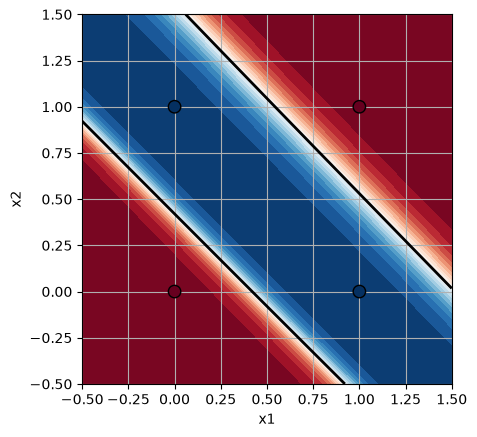

In [8]:
def plot_decision_2d(model, X, t, lim=(-0.5, 1.5)):
    xx, yy = np.meshgrid(np.linspace(lim[0], lim[1], 200), np.linspace(lim[0], lim[1], 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu")
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=t.ravel(), edgecolors="k", s=80, cmap="RdBu", vmin=0, vmax=1, zorder=3)
    ax.set_aspect("equal")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.grid(True)

plot_decision_2d(model_xor, X_xor, t_xor)

## 5. Généralisation : MLP à $n$ couches

Le perceptron à une couche cachée est le cas $L = 2$. Pour apprendre des fonctions plus complexes, on **empile** $L$ couches. La classe générique `MLP(sizes)` prend `sizes=[d, h1, …, k]` pour décrire l'architecture.

Convention **ligne** : chaque échantillon est une ligne de la matrice. Pour un batch $X$ de taille $(N, d)$ :

### Notations

| Symbole | Signification |
|---|---|
| $N$ | nombre d'échantillons du batch |
| $d$ | nombre de features en entrée |
| $L$ | nombre de couches |
| $l$ | indice de couche, $l = 1, \dots, L$ |
| $X$ | batch d'entrée, de forme $(N, d)$ |
| $Y_0$ | activations de la couche d'entrée ($Y_0 = X$) |
| $W_l$ | matrice de poids de la couche $l$, de forme $(n_{out}, n_{in})$ |
| $b_l$ | biais de la couche $l$, de forme $(n_{out},)$ |
| $Z_l$ | pré-activations de la couche $l$ (avant activation) |
| $Y_l$ | activations de la couche $l$, de forme $(N, n_{out})$ |
| $A$ | fonction d'activation des couches cachées (`activation`) ; $A'$ sa dérivée |
| $A_o$ | fonction d'activation de la couche de sortie (`output_activation`) ; $A_o'$ sa dérivée |
| $Y$ | sortie du réseau, $Y = Y_L$ |
| $T$ | cibles, de même forme que $Y$ |
| $E$ | coût (erreur quadratique moyenne) |
| $\delta_l$ | erreur rétropropagée, $\delta_l = \frac{\partial E}{\partial Z_l}$ |
| $\odot$ | produit terme à terme (Hadamard) |

### Passe avant

$$Y_0 = X,\qquad Z_l = Y_{l-1} W_l^T + b_l,\qquad Y_l = A(Z_l) \;\; (l < L),\qquad Y = Y_L = A_o(Z_L)$$

### Coût

$$E = \tfrac12\,\operatorname{mean}\big((Y - T)^2\big)$$

### Passe arrière

$$\delta_L = (Y - T)\odot A_o'(Z_L)$$

$$\delta_l = (\delta_{l+1}\,W_{l+1})\odot A'(Z_l)$$

$$\frac{\partial E}{\partial W_l} = \frac{1}{N}\,\delta_l^T Y_{l-1},\qquad \frac{\partial E}{\partial b_l} = \frac{1}{N}\sum_i \delta_l$$

Les couches cachées utilisent `activation` (fonction $A$) ; la couche de sortie utilise `output_activation` (fonction $A_o$).

> **Exercice 6** — Complétez `forward` et `backward` (version en boucle sur les couches), puis `fit_batch` : descente de gradient par lot simple (une étape par epoch, historique du coût d'entraînement).

In [9]:
class MLP:
    def __init__(self, sizes, activation="sigmoid", output_activation="linear", seed=0):
        rng = np.random.default_rng(seed)
        self.sizes = list(sizes)
        self.Ws = []
        self.bs = []
        for n_in, n_out in zip(sizes[:-1], sizes[1:]):
            self.Ws.append(rng.normal(0.0, 0.5, size=(n_out, n_in)))
            self.bs.append(np.zeros(n_out))
        self.activation, self.activation_prime = ACTIVATIONS[activation]
        self.output_activation, self.output_activation_prime = ACTIVATIONS[output_activation]

    def predict(self, X):
        return self.forward(X)[0][-1]

    def loss(self, X: np.ndarray, t: np.ndarray) -> float:
        """Coût du modèle : erreur quadratique moyenne.

        E = (1/2) · mean(Σ_k (Y_k - T_k)²).

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).

        Returns
        -------
        float
            Coût quadratique moyen sur le batch.
        """
        # coût du cours : moyenne sur les échantillons de 1/2 · Σ_k (Y_k - T_k)^2
        # BEGIN
        return 0.5 * float(np.mean(np.sum((self.predict(X) - t) ** 2, axis=1)))
        # END



    def forward(self, X: np.ndarray) -> tuple[list[np.ndarray], list[np.ndarray]]:
        """Passe avant du MLP, couche par couche.

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).

        Returns
        -------
        tuple[list[np.ndarray], list[np.ndarray]]
            (As, Zs) : activations (avec Y0 = X en tête) et pré-activations
            de chaque couche.
        """
        # BEGIN
        A = X
        As = [A]
        Zs = []
        n = len(self.Ws)
        for l, (W, b) in enumerate(zip(self.Ws, self.bs)):
            Z = A @ W.T + b
            Zs.append(Z)
            f = self.output_activation if l == n - 1 else self.activation
            A = f(Z)
            As.append(A)
        return As, Zs
        # END

    def backward(self, X: np.ndarray, t: np.ndarray) -> list[tuple[np.ndarray, np.ndarray]]:
        """Passe arrière : gradients du coût pour chaque couche.

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).

        Returns
        -------
        list[tuple[np.ndarray, np.ndarray]]
            Liste de (dW_l, db_l), une paire de gradients par couche.
        """
        # BEGIN
        As, Zs = self.forward(X)
        N = X.shape[0]
        n = len(self.Ws)
        delta = (As[-1] - t) * self.output_activation_prime(Zs[-1])
        dWs, dbs = [], []
        for l in range(n - 1, -1, -1):
            dW = delta.T @ As[l] / N
            db = delta.sum(axis=0) / N
            dWs.insert(0, dW)
            dbs.insert(0, db)
            if l > 0:
                delta = (delta @ self.Ws[l]) * self.activation_prime(Zs[l - 1])
        return list(zip(dWs, dbs))
        # END

    def step(self, X: np.ndarray, t: np.ndarray, lr: float) -> None:
        """Effectue une étape de descente de gradient (mise à jour des poids).

        Parameters
        ----------
        X : np.ndarray
            Batch d'entrée, de forme (N, d).
        t : np.ndarray
            Cibles, de même forme que la sortie du réseau (N, k).
        lr : float
            Pas d'apprentissage.
        """
        # BEGIN
        for l, (dW, db) in enumerate(self.backward(X, t)):
            self.Ws[l] -= lr * dW
            self.bs[l] -= lr * db
        # END

    def fit_batch(self, X: np.ndarray, t: np.ndarray, lr: float = 0.1, epochs: int = 2000) -> list[float]:
        """Entraîne le MLP par descente de gradient par lot.

        Parameters
        ----------
        X : np.ndarray
            Batch d'entraînement, de forme (N, d).
        t : np.ndarray
            Cibles d'entraînement, de forme (N, k).
        lr : float, optionnel
            Pas d'apprentissage (défaut : 0.1).
        epochs : int, optionnel
            Nombre maximal d'epochs (défaut : 2000).

        Returns
        -------
        list[float]
            Historique du coût d'entraînement, un élément par epoch.
        """
        # BEGIN
        history = []
        for epoch in range(epochs):
            self.step(X, t, lr)
            history.append(self.loss(X, t))
        return history
        # END


## 6. Fonction 1D : apprendre $f(x) = \sin(x)$

Régression cette fois : sortie **linéaire** (pas de sigmoïde), données bruitées, séparation **train/test**.

> **Exercice 7a** — Séparez aléatoirement en train (60 points) et test (le reste), puis entraînez avec `fit_batch` sur le **train uniquement** (beaucoup d'epochs).

In [10]:
def gen_1d(n=300, noise=0.1, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-np.pi, np.pi, size=(n, 1))
    t = np.sin(X) + rng.normal(0.0, noise, size=(n, 1))
    return X, t

X1, t1 = gen_1d()

In [11]:
# BEGIN
rng = np.random.default_rng(0)
idx = rng.permutation(len(X1))
n_train = 60
X_train, t_train = X1[idx[:n_train]], t1[idx[:n_train]]
X_test, t_test = X1[idx[n_train:]], t1[idx[n_train:]]

model_1d = MLP([1, 32, 32, 1], activation="tanh", output_activation="linear", seed=0)
hist_1d = model_1d.fit_batch(X_train, t_train, lr=0.05, epochs=50000)
print("coût train final :", hist_1d[-1])
print("coût test  final :", model_1d.loss(X_test, t_test))
# END


coût train final : 0.003705838461664894
coût test  final : 0.005268246706520021


`fit_batch` entraîne un nombre d'epochs fixe : rien n'empêche le réseau de **surapprendre** le train (le coût train baisse encore alors que le coût test remonte). L'**early stopping** arrête l'apprentissage quand la performance sur le test se dégrade.

> **Exercice 7b** — Implémentez `fit_early_stopping` : à chaque epoch on évalue le coût sur le **test**, on garde les meilleurs poids, on s'arrête après `patience` epochs sans amélioration, puis on restaure les meilleurs poids. Ajoutez-la à `MLP`.

In [12]:
def fit_early_stopping(self, X, t, X_test, t_test, lr=0.1, epochs=2000, patience=200):
    """Entraîne le MLP par descente de gradient par lot avec early stopping.

    À chaque epoch on évalue le coût sur le jeu de test ; on conserve les
    meilleurs poids ; on s'arrête après ``patience`` epochs sans amélioration.

    Returns
    -------
    dict[str, list[float]]
        Historique des coûts ``{"train": [...], "test": [...]}``.
    """
    # BEGIN
    history = {"train": [], "test": []}
    best_test = np.inf
    best = None
    no_improve = 0
    for epoch in range(epochs):
        self.step(X, t, lr)
        history["train"].append(self.loss(X, t))
        te = self.loss(X_test, t_test)
        history["test"].append(te)
        if te < best_test:
            best_test = te
            best = (copy.deepcopy(self.Ws), copy.deepcopy(self.bs))
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    if best is not None:
        self.Ws, self.bs = best
    return history
    # END


MLP.fit_early_stopping = fit_early_stopping


> **Exercice 7c** — Entraînez un **nouveau** réseau avec `fit_early_stopping` puis tracez l'historique : que fait l'erreur train ? l'erreur test ? À quoi sert l'early stopping ici ?

In [ ]:
# BEGIN
model_es = MLP([1, 32, 32, 1], activation="tanh", output_activation="linear", seed=0)
hist_es = model_es.fit_early_stopping(X_train, t_train, X_test, t_test, lr=0.05, epochs=50000, patience=4000)
# END


In [ ]:
def plot_history(history, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(history["train"], label="train")
    if history["test"]:
        ax.plot(history["test"], label="test")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True)
    return ax

plot_history(hist_es)

Comparons la prédiction du réseau à la vraie fonction $\sin(x)$.

In [ ]:
def plot_fit_1d(model, X, t, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    grid = np.linspace(-np.pi, np.pi, 300).reshape(-1, 1)
    ax.plot(grid.ravel(), np.sin(grid).ravel(), label="sin(x)", color="tab:green", lw=2)
    ax.plot(grid.ravel(), model.predict(grid).ravel(), label="prédiction", color="tab:red", lw=2, ls="--")
    ax.scatter(X.ravel(), t.ravel(), s=15, alpha=0.5, label="données (train)", color="tab:blue")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(); ax.grid(True)
    return ax

plot_fit_1d(model_es, X_train, t_train)

## 7. Fonction 2D : $f(x_1, x_2) = \sin(x_1)\cos(x_2)$

Même principe, deux entrées. On visualise la surface prédite en 3D avec **plotly**.

> **Exercice 8** — Séparez train/test, entraînez `[2, 16, 16, 1]` avec `fit_early_stopping`, puis visualisez.

In [ ]:
%pip install plotly

In [ ]:
def gen_2d(n=500, noise=0.1, seed=1):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-3.0, 3.0, size=(n, 2))
    t = (np.sin(X[:, 0]) * np.cos(X[:, 1])).reshape(-1, 1) + rng.normal(0.0, noise, size=(n, 1))
    return X, t

X2, t2 = gen_2d()

In [ ]:
# BEGIN
rng = np.random.default_rng(1)
idx = rng.permutation(len(X2))
n_train = 400
X2_train, t2_train = X2[idx[:n_train]], t2[idx[:n_train]]
X2_test, t2_test = X2[idx[n_train:]], t2[idx[n_train:]]

model_2d = MLP([2, 16, 16, 1], activation="tanh", output_activation="linear", seed=0)
hist_2d = model_2d.fit_early_stopping(X2_train, t2_train, X2_test, t2_test, lr=0.2, epochs=30000, patience=2000)
# END

In [ ]:
import plotly.graph_objects as go

def plot_surface_3d(model, x1, x2):
    xx, yy = np.meshgrid(x1, x2)
    G = np.c_[xx.ravel(), yy.ravel()]
    Z_pred = model.predict(G).reshape(xx.shape)
    Z_true = np.sin(xx) * np.cos(yy)
    fig = go.Figure()
    fig.add_trace(go.Surface(x=x1, y=x2, z=Z_true, colorscale="Viridis", opacity=0.9, name="vraie", showscale=False))
    fig.add_trace(go.Surface(x=x1, y=x2, z=Z_pred, colorscale="Reds", opacity=0.9, name="prédite", showscale=False))
    fig.update_layout(title="Fonction 2D : vraie (vert) vs prédite (rouge)", height=600,
                      scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="f"))
    fig.show()

x1 = np.linspace(-3, 3, 50)
x2 = np.linspace(-3, 3, 50)
plot_surface_3d(model_2d, x1, x2)

## 8. Élan (momentum)

La descente de gradient par lot (section 7) avance à petits pas, surtout dans les vallées étroites de la surface d'erreur où elle **zigzague**. L'**élan** (momentum) ajoute une « inertie » : au lieu de déplacer $W$ selon le gradient brut, on déplace selon une **vitesse** $v$ qui mélange le gradient courant et la vitesse précédente.

$$v_l \leftarrow \mu\, v_l + \eta\, \frac{\partial E}{\partial W_l}, \qquad W_l \leftarrow W_l - v_l$$

- $\mu$ : coefficient d'élan, $0 \le \mu < 1$ (typiquement $0.9$). $\mu = 0$ redonne la descente de gradient classique.
- $\eta$ : pas d'apprentissage (`lr`).
- $v_l$ : vitesse associée à $W_l$, même forme que $W_l$, initialisée à $0$.

> **Exercice 9** — Héritez de `MLP` pour implémenter l'élan. La classe de base garde une méthode `step` **sans élan** (simple descente de gradient) ; une sous-classe `MLPMomentum(MLP)` ajoute des vitesses `vWs`/`vbs` (mêmes formes que `Ws`/`bs`, nulles au départ) et **surcharge** `step` pour appliquer la règle ci-dessus. Entraînez le problème 2D **avec** ($\mu = 0.9$) et **sans** ($\mu = 0$) élan — même graine, même `lr`, même nombre d'epochs — puis comparez les courbes de coût.


In [ ]:
class MLPMomentum(MLP):
    def __init__(self, sizes, activation="sigmoid", output_activation="linear", seed=0, momentum=0.9):
        super().__init__(sizes, activation, output_activation, seed)
        self.momentum = momentum
        self.vWs = [np.zeros_like(W) for W in self.Ws]
        self.vbs = [np.zeros_like(b) for b in self.bs]

    def step(self, X: np.ndarray, t: np.ndarray, lr: float) -> None:
        """Une étape de descente de gradient avec élan (momentum).

        v_l <- mu * v_l + lr * dW_l ; W_l <- W_l - v_l.
        """
        # BEGIN
        for l, (dW, db) in enumerate(self.backward(X, t)):
            self.vWs[l] = self.momentum * self.vWs[l] + lr * dW
            self.vbs[l] = self.momentum * self.vbs[l] + lr * db
            self.Ws[l] -= self.vWs[l]
            self.bs[l] -= self.vbs[l]
        # END

In [ ]:
# BEGIN
lr = 0.2
epochs = 20000

model_plain = MLP([2, 16, 16, 1], activation="tanh", output_activation="linear", seed=0)
hist_plain = model_plain.fit_batch(X2_train, t2_train, lr=lr, epochs=epochs)

model_mom = MLPMomentum([2, 16, 16, 1], activation="tanh", output_activation="linear", seed=0, momentum=0.9)
hist_mom = model_mom.fit_batch(X2_train, t2_train, lr=lr, epochs=epochs)
# END

fig, ax = plt.subplots()
ax.plot(hist_plain, label="sans élan (μ=0)")
ax.plot(hist_mom, label="avec élan (μ=0.9)")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_yscale("log"); ax.legend(); ax.grid(True)


## 9. Bonus

- **Perceptron à une couche cachée** : que se passe-t-il si on prend 2 ou 3 neurones cachés pour XOR au lieu de 4 ?
- **Activations** : comparez sigmoïde vs tanh sur XOR (vitesse, nombre d'epochs).
- **Early stopping** : réglez `patience` très faible puis très élevée — où s'arrête l'apprentissage ?
- **Autres fonctions** : testez d'autres fonctions (ex. $f(x) = x^2$, $f(x_1,x_2) = x_1^2 + x_2^2$) ou plus de bruit : où le réseau échoue-t-il ?